# 회귀분석

In [1]:
%run  start.py

In [2]:
w = pd.read_csv('data/chick004.csv')
w

,chick_nm,weight,egg_weight,movement,food
0,a01,140,65,146,14
1,a02,128,62,153,12
2,a03,140,65,118,13
3,a04,135,65,157,13
4,a05,145,69,157,13
5,a06,138,65,143,13
6,a07,125,61,110,11
7,a08,148,69,159,15
8,a09,133,64,133,11
9,a10,145,69,174,13


In [3]:
 w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   chick_nm    30 non-null     object
 1   weight      30 non-null     int64 
 2   egg_weight  30 non-null     int64 
 3   movement    30 non-null     int64 
 4   food        30 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.3+ KB


In [4]:
w2 = w.iloc[ : , 1:5]
w2

,weight,egg_weight,movement,food
0,140,65,146,14
1,128,62,153,12
2,140,65,118,13
3,135,65,157,13
4,145,69,157,13
5,138,65,143,13
6,125,61,110,11
7,148,69,159,15
8,133,64,133,11
9,145,69,174,13


## statsmodels라이브러리의 OLS 이용한 단순회귀분석

In [5]:
import statsmodels.formula.api as smf

In [6]:
# 1. 모델생성
# 종란무게 - 병아리무게 단순선형회귀모델 구축
model_lm = smf.ols(formula = 'weight ~ egg_weight', data = w2)

In [7]:
## 2. 모델 학습
result_lm = model_lm.fit()

In [8]:
## 3. 모델 결과 확인
result_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 weight   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     306.0
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           1.32e-16
Time:                        09:31:54   Log-Likelihood:                -63.148
No. Observations:                  30   AIC:                             130.3
Df Residuals:                      28   BIC:                             133.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -14.5475      8.705     -1.671      0.106     -32.380       3.285
egg_weight     2.3371      0.134     17.493      0.000       2.063       2.611
==============================================================================
Omnibus:                       15.078   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.001   Jarque-Bera (JB):                2.750
Skew:                           0.032   Prob(JB):                        0.253
Kurtosis:                       1.518   Cond. No.                     1.51e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

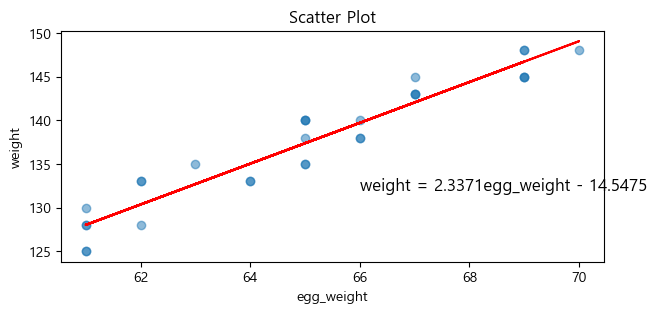

In [9]:
# 종란무게에 따른 병아리무게 산점도
plt.figure(figsize = (7,3))

plt.scatter(w.egg_weight, w.weight, alpha = .5)
plt.plot(w.egg_weight, w.egg_weight*2.3371 - 14.5475, color = 'red')

plt.text(66, 132, 'weight = 2.3371egg_weight - 14.5475', fontsize = 12)
plt.title('Scatter Plot')
plt.xlabel('egg_weight')
plt.ylabel('weight')
plt.show()

## sklearn 라이브러리 LinearRegression 이용한 단순회귀분석

In [10]:
from sklearn.linear_model import LinearRegression
# from sklearn import set_config
# set_config(display="text")

In [11]:
x = w2[['egg_weight']]     ## 독립변수
y = w2['weight']   ## 종속변수

In [12]:
# 모델 생성 및 학습
model = LinearRegression()
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(x)
y_pred

array([137.36628644, 130.35487959, 137.36628644, 137.36628644,
       146.7148289 , 137.36628644, 128.01774398, 146.7148289 ,
       135.02915082, 146.7148289 , 142.04055767, 128.01774398,
       130.35487959, 142.04055767, 146.7148289 , 128.01774398,
       149.05196451, 128.01774398, 142.04055767, 146.7148289 ,
       128.01774398, 135.02915082, 139.70342205, 142.04055767,
       137.36628644, 139.70342205, 137.36628644, 139.70342205,
       130.35487959, 132.69201521])

In [14]:
x2 =np.array([55,44,58,61,72,68]).reshape(-1,1)
model.predict(x2)

array([113.99493029,  88.28643853, 121.00633714, 128.01774398,
       153.72623574, 144.37769328])

In [15]:
## 모델 결과
coef = model.coef_[0]  # 회귀계수 (기울기)
intercept = model.intercept_  # 절편
print(f"회귀식: weight = {coef:.4f} * egg_weight + {intercept:.4f}")

회귀식: weight = 2.3371 * egg_weight + -14.5475


## 다중회귀분석

In [16]:
model2 = smf.ols(formula = 'weight ~ egg_weight + food + movement', data = w2)
result2 = model2.fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 weight   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     157.7
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           8.46e-17
Time:                        09:50:57   Log-Likelihood:                -56.008
No. Observations:                  30   AIC:                             120.0
Df Residuals:                      26   BIC:                             125.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9748      8.587      0.346      0.732     -14.676      20.626
egg_weight     1.7763      0.195      9.117      0.000       1.376       2.177
food           1.5847      0.405      3.915      0.001       0.753       2.417
movement      -0.0087      0.017     -0.522      0.606      -0.043       0.026
==============================================================================
Omnibus:                        1.993   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.369   Jarque-Bera (JB):                1.746
Skew:                          -0.480   Prob(JB):                        0.418
Kurtosis:                       2.311   Cond. No.                     4.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
x = w2[["egg_weight", "food"]] 
y = w2["weight"] 
# 모델 생성 및 학습
model3 = LinearRegression()
model3.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
print("Intercept (절편):", model3.intercept_)
print("Coefficients (회귀 계수):", model3.coef_)

Intercept (절편): 3.663849948713022
Coefficients (회귀 계수): [1.74532311 1.5954672 ]
